# Import and Data filtering

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

YIELD_IS_PERCENT = True

AttributeError: partially initialized module 'pandas' has no attribute 'core' (most likely due to a circular import)

In [ ]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

# Ensure the timestamp is datetime
data["time_stamp"] = pd.to_datetime(data["time_stamp"])

# Sort by ISIN and timestamp to get the correct last entry
data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = data["time_stamp"].dt.date
data.head()

,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


In [ ]:
# Parse timestamp BEFORE sorting/resampling
#data["time_stamp"] = pd.to_datetime(data["time_stamp"], utc=True)

# Consistent typing on mat_cat (string is safer for column labels)
data["mat_cat"] = data["mat_cat"].astype(str)

# Sort within each contract series
data = data.sort_values(["isin", "time_stamp"]).reset_index(drop=True)

# --- Δy by ISIN (no cross-ISIN leakage) ---
# If yield is in percent (e.g., 0.4835%), convert to decimal before differencing
if YIELD_IS_PERCENT:
    y_level = data["yield"] / 100.0
else:
    y_level = data["yield"]

data["dy"] = y_level.groupby(data["isin"]).diff()  # Δy in decimal (e.g., 1 bp = 0.0001)

# Also keep Δy in bp if needed
data["dy_bp"] = data["dy"] * 1e4  # basis points

# (Futures) We will build a *risk-normalized* return per unit DV01 next.
# For IR futures, linearized PnL ≈ - DV01 * Δy. Per unit DV01, return ≈ -Δy.
# This avoids notional/DV01 scaling headaches at optimization time.
data["r_per_DV01"] = -data["dy_bp"]*data["dv01"]  # per DV01 standardized return (dimensionless)

data["daily_coupon"] = data['yield'].shift(1)*(1/252)/100 #pour enlever le pourcent  

data["total_ret"] = data["r_per_DV01"] + data["daily_coupon"] 

C:\Users\hugoj\AppData\Local\Temp\ipykernel_17320\1640781942.py:23: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  (data["time_stamp"] >= pd.to_datetime(start_date)) &
C:\Users\hugoj\AppData\Local\Temp\ipykernel_17320\1640781942.py:24: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  (data["time_stamp"] <= pd.to_datetime(end_date))


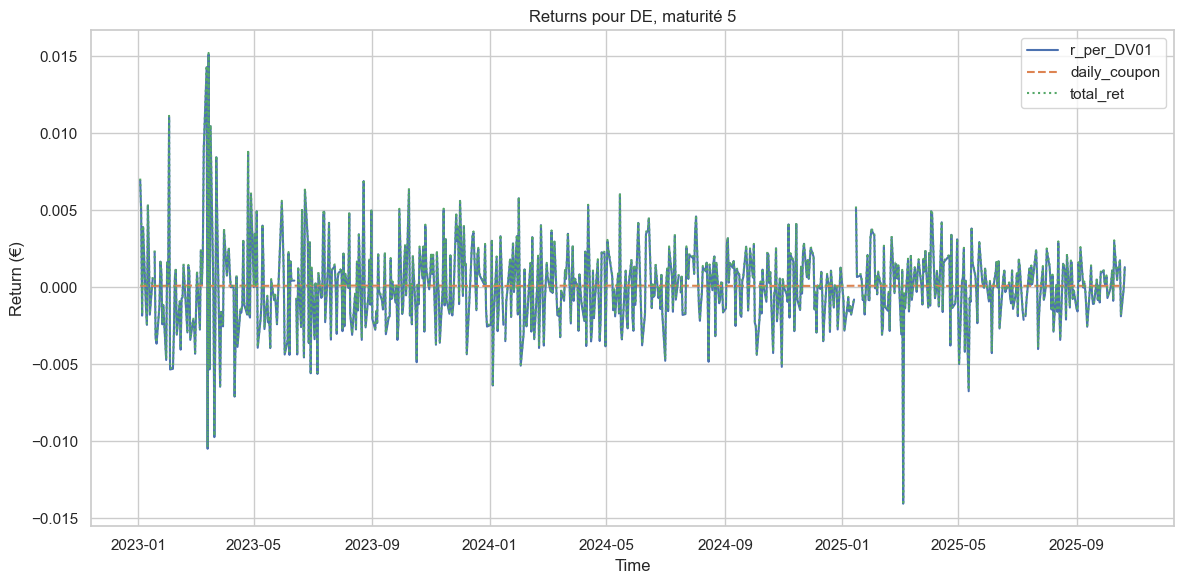

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "r_per_DV01"   # Colonne de return DV01
return_col2 = "daily_coupon" # Colonne de coupon quotidien
return_col3 = "total_ret"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col1], label=return_col1, linestyle="-")
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="--")
plt.plot(df_plot["time_stamp"], df_plot[return_col3], label=return_col3, linestyle=":")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Bonne tête de return !

# Estimation des return

In [ ]:
val = "total_ret"  # standardized return per DV01

def make_panel(df_country):
    wide = df_country.pivot(index="time_stamp", columns="mat_cat", values=val)
    # Aggregate intraday to daily by summing Δy contributions
    daily = wide#.resample("1D").sum(min_count=1)
    return daily

df_FR = make_panel(data[data["country_iso"] == "FR"])
df_DE = make_panel(data[data["country_iso"] == "DE"])
df_IT = make_panel(data[data["country_iso"] == "IT"])

# Optional: drop all-empty days only (keep pairwise NA for cov estimation later)
for k, df in [("FR", df_FR), ("DE", df_DE), ("IT", df_IT)]:
    pass  # no full dropna here; we’ll handle pairwise later

In [ ]:
from scipy.optimize import minimize

class Portfolio:
    def __init__(self, data_dict, date, benchmark="ew", long_only=True, lamb=1.0, ridge=1e-3, window_days=None, sigma_level = 0.01):
        """
        data_dict: dict[str -> DataFrame]
            Each DataFrame has DatetimeIndex (daily) and columns = mat_cat (strings).
            Values are per-DV01 standardized returns (dimensionless).
        date: datetime-like
            Rebalance (estimation) date. Uses history up to and including this date.
        long_only: if True, project to simplex after solving (approximate).
        lamb: risk-aversion for mean-variance utility: maximize mu'w - lambda * w'Σw.
        ridge: diagonal shrinkage added to Σ for stability.
        window_days: if set, only use last N calendar days of history for μ, Σ.
        """
        self.data = data_dict
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.long_only = long_only
        self.lamb = float(lamb)
        self.ridge = float(ridge)
        self.window_days = window_days
        self.benchmark_weights = None
        self.sigma_level = sigma_level

    def get_returns_until(self):
        """Concat all country panels into a single wide panel up to self.date."""
        frames = []

        for country, df in self.data.items():
            tmp = df.loc[: self.date]
            # Add country prefix so column names are unique/stable
            tmp = tmp.add_prefix(f"{country}_")
            frames.append(tmp)
        R = pd.concat(frames, axis=1)

        if self.window_days is not None:
            start_cut  = self.date - pd.Timedelta(days=int(self.window_days))
            R = R.loc[R.index >= start_cut]

        # Do not drop to full intersection early; compute pairwise μ, Σ
        self.returns = R

    def estimate_returns(self):
        """Sample mean per column (ignores NA)."""
        self.mean_returns = self.returns.mean(skipna=True)

    def estimate_cov_matrix(self):
        """Pairwise covariance with ridge shrinkage."""
        Sigma = self.returns.cov(min_periods=30)  # require some overlap
        # Ridge shrinkage on diagonal
        #d = np.asarray(Sigma.columns)
        la = 1e-2
        Sigma = (1-la)*Sigma +  la*np.eye(Sigma.shape[0])
        self.cov_matrix = pd.DataFrame(Sigma, index=self.mean_returns.index, columns=self.mean_returns.index)
        #self.cov_matrix = self.returns.cov(min_periods=30)

    def simple_markowitz(self, budget="sum_abs=1", normalize=False):
        """
        Solve w = (1/(2λ)) Σ^{-1} μ (unconstrained), then apply:
          - optional long-only projection (approximate: clip negatives then renormalize)
          - budget scaling:
              * 'sum=1'     -> sum(w) = 1
              * 'sum_abs=1' -> sum(|w|) = 1  (controls gross DV01 exposure)
          Note: here weights are DV01 exposures since returns are per-DV01.
        """
        mu = self.mean_returns.values
        Sigma = self.cov_matrix.values

        # Prefer solve over inverse for stability
        try:
            w = np.linalg.solve(2.0 * self.lamb * Sigma, mu)
        except np.linalg.LinAlgError:
            # Fallback with a bit more ridge
            Sigma_fallback = Sigma + 10.0 * self.ridge * np.eye(Sigma.shape[0])
            w = np.linalg.solve(2.0 * self.lamb * Sigma_fallback, mu)

        if self.long_only:
            w = np.maximum(w, 0.0)
            s = w.sum()
            if s > 0:
                w = w / s
        else:
            if normalize or (budget is not None):
                if budget == "sum=1":
                    s = w.sum()
                    if s != 0:
                        w = w / s
                elif budget == "sum_abs=1":
                    g = np.abs(w).sum()
                    if g != 0:
                        w = w / g
                elif budget is None:
                    pass
                else:
                    raise ValueError(f"Unknown budget: {budget}")

        self.weights = pd.DataFrame(w, index=self.mean_returns.index, columns=[self.date])
    
    def markowitz2(self):
        """
        Optimisation Markowitz (long-only) avec contrainte de risque.

        Arguments:
            mean_returns : array (n,) des rendements attendus
            cov_matrix   : array (n,n) matrice de covariance
            sigma_level  : float, risque maximal autorisé (w.T @ Sigma @ w)
            long_only    : bool, wi >= 0 si True

        Retourne :
            w_opt : array (n,) des poids optimaux
        """
        cov_matrix = self.cov_matrix
        mean_returns = self.mean_returns
        n = len(self.mean_returns)
        sigma_level = self.sigma_level
        
        # Fonction objectif : maximiser V = w.T @ R sous contrainte, on minimise -V
        def objective(w):
            return -w @ mean_returns  # négatif car on maximise

        # Gradient analytique
        def grad_objective(w):
            return -mean_returns  # gradient = -R

        # Contraintes
        constraints = []

        # 1. Somme des poids = 1
        constraints.append({'type': 'eq', 'fun': lambda w: np.sum(w) - 1,
                            'jac': lambda w: np.ones_like(w)})

        # 2. Risque total <= sigma_level
        def risk_fun(w):
            return w @ cov_matrix @ w - sigma_level
        def grad_risk(w):
            return 2 * cov_matrix @ w
        constraints.append({'type': 'ineq', 'fun': lambda w: sigma_level - w @ cov_matrix @ w,
                            'jac': lambda w: -grad_risk(w)})  # scipy expects fun >= 0

        # 3. Long only
        bounds = [(0, 1) if self.long_only else (None, None)] * n

        # Initial guess à changer après avec la pf précédent
        w0 = np.ones(n) / n

        # Minimisation
        res = minimize(objective, w0, jac=grad_objective,
                    bounds=bounds, constraints=constraints,
                    method='SLSQP', options={'ftol': 1e-9, 'disp': False, 'maxiter':1000})

        if not res.success:
            raise ValueError("Optimisation échouée: " + res.message)

        res.x[res.x < 1e-9] = 0.0

        # Renormaliser pour que la somme = 1
        if res.x.sum() > 0:
            res.x = res.x / res.x.sum()
        
        self.weights = pd.DataFrame(res.x, index=self.mean_returns.index, columns=[self.date])
        


    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n, index=self.mean_returns.index, columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix()
        #self.simple_markowitz(budget="sum_abs=1")  # consistent gross DV01 = 1
        self.markowitz2() #paramètre très sensible
        self.benchmark_w()
        return self.weights


In [ ]:
df_FR.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12',
               '2015-01-13', '2015-01-14',
               ...
               '2025-10-08', '2025-10-09', '2025-10-10', '2025-10-13',
               '2025-10-14', '2025-10-15', '2025-10-16', '2025-10-17',
               '2025-10-20', '2025-10-21'],
              dtype='datetime64[ns]', name='time_stamp', length=2232, freq=None)

In [ ]:
data_dict = {"FR": df_FR, "DE": df_DE, "IT": df_IT}
for c in list(data_dict):
    # keep as-is; no full dropna here
    pass

date = "2023-06-01 00:00:00+00:00"


pf = Portfolio(data_dict, date, benchmark="ew", long_only=True, window_days=100, sigma_level=0.002)
w = pf.process() 
print(w)

C:\Users\hugoj\AppData\Local\Temp\ipykernel_17320\514554232.py:35: FutureWarning: Indexing a timezone-naive DatetimeIndex with a timezone-aware datetime is deprecated and will raise KeyError in a future version.  Use a timezone-naive object instead.
  tmp = df.loc[: self.date]
C:\Users\hugoj\AppData\Local\Temp\ipykernel_17320\514554232.py:35: FutureWarning: Indexing a timezone-naive DatetimeIndex with a timezone-aware datetime is deprecated and will raise KeyError in a future version.  Use a timezone-naive object instead.
  tmp = df.loc[: self.date]
C:\Users\hugoj\AppData\Local\Temp\ipykernel_17320\514554232.py:35: FutureWarning: Indexing a timezone-naive DatetimeIndex with a timezone-aware datetime is deprecated and will raise KeyError in a future version.  Use a timezone-naive object instead.
  tmp = df.loc[: self.date]


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp

## Creation du time series portfolio

In [ ]:
class TimeSeriesPortfolio:
    def __init__(self, data_dict, start_date, end_date, rebalance_freq='1M', long_only=False, lamb=1.0, benchmark="ew", ridge=1e-3, window_days=None):
        self.data_dict = data_dict
        self.start_date = pd.to_datetime(start_date, utc=True)
        self.end_date = pd.to_datetime(end_date, utc=True)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.ridge = float(ridge)
        self.window_days = window_days

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}

        # Build a single wide matrix once: Date × Asset (per-DV01 returns)
        frames = []
        for country, df in self.data_dict.items():
            frames.append(df.add_prefix(f"{country}_"))
        self.R = pd.concat(frames, axis=1).sort_index()
        # Keep only requested backtest window (with a small lead for windowing)
        self.R = self.R.loc[(self.R.index >= (self.start_date - pd.Timedelta(days=5_000))) & (self.R.index <= self.end_date)]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f.endswith(('D', 'B', 'W', 'M')):
            return f
        return '1M'

    def generate_rebalance_dates(self):
        all_dates = self.R.index.unique()
        all_dates = all_dates[(all_dates >= self.start_date) & (all_dates <= self.end_date)]
        all_dates = all_dates.sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date.normalize(), end=self.end_date.normalize(), freq=self.freq_to_pd_freq(), tz="UTC")
        reb = []
        for tgt in targets:
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)
        return self.rebalance_dates, self.all_dates

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        pf_weights = []
        bm_weights = []
        pf_returns = []
        bm_returns = []
        returns_dates = []

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]

            pf = Portfolio(
                data_dict=self.data_dict,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                ridge=self.ridge,
                window_days=self.window_days
            )
            w_df = pf.process()  # weights indexed by asset names (e.g., 'FR_2', 'DE_10', ...)
            w = w_df.iloc[:, 0]  # pandas Series, preserves index order

            # Align the return matrix columns EXACTLY to weight index
            cols = w.index.tolist()
            # Period returns: (t, t_next] (no look-ahead)
            period_mask = (self.R.index > t) & (self.R.index <= t_next)
            R_slice = self.R.loc[period_mask, cols]

            # Compute portfolio/benchmark PnL in risk units (per-DV01 returns × DV01 exposure)
            # (Sum over dates) of (R @ w)
            vec_pf = (R_slice.fillna(0.0) @ w.values)
            vec_bm = (R_slice.fillna(0.0) @ pf.benchmark_weights.iloc[:, 0].reindex(cols).values)

            pf_returns.extend(vec_pf.tolist())
            bm_returns.extend(vec_bm.tolist())
            returns_dates.extend(R_slice.index.tolist())

            pf_weights.append(w.values)
            bm_weights.append(pf.benchmark_weights.iloc[:, 0].reindex(cols).values)

        asset_names = w.index if 'w' in locals() else [f"a{i}" for i in range(len(pf_weights[0]))]
        self.weights_history = pd.DataFrame(pf_weights, index=self.rebalance_dates[:-1], columns=asset_names)

        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_returns, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_returns, index=pd.DatetimeIndex(returns_dates))
        else:
            self.portfolio_returns = pd.Series(dtype=float)
            self.benchmark_returns = pd.Series(dtype=float)

        if not self.portfolio_returns.empty:
            self.metrics = {
                "pf_cumulative_return": (1 + self.portfolio_returns.fillna(0)).cumprod(),
                "bm_cumulative_return": (1 + self.benchmark_returns.fillna(0)).cumprod(),
                "pf_cumsum_return": (self.portfolio_returns.fillna(0)).cumsum(),
                "bm_cumsum_return": (self.benchmark_returns.fillna(0)).cumsum(),
                "mean_return": self.portfolio_returns.mean(),
                "volatility": self.portfolio_returns.std(),
                "sharpe": (self.portfolio_returns.mean() / self.portfolio_returns.std()) if self.portfolio_returns.std() != 0 else np.nan,
                "gross_exposure": np.abs(self.weights_history).sum(axis=1),
                "net_exposure": self.weights_history.sum(axis=1)
            }
        else:
            self.metrics = {}

        return self.weights_history, self.portfolio_returns, self.benchmark_returns

    def plot_weights(self):
        if self.weights_history.empty:
            raise ValueError("Aucune donnée de portefeuille. Lancez generate_portfolios()")
        
        
        
        # --- Plot somme des poids (check si long-only normalisé) ---
        if self.long_only:
            plt.figure(figsize=(14, 6))
            
            # --- Plot stacked area pour visualiser les poids ---
            self.weights_history.plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.7)
            
            plt.title("Historique des poids du portefeuille (stacked)")
            plt.xlabel("Date")
            plt.ylabel("Poids")
            plt.legend(loc='upper left', bbox_to_anchor=(1,1))
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(14,3))
            plt.plot(self.weights_history.sum(axis=1), marker='o', linestyle='-')
            plt.title("Somme des poids par date (doit être 1 si long-only)")
            plt.xlabel("Date")
            plt.ylabel("Somme des poids")
            plt.grid(True)
            plt.show()

        else :
            # --- Pour long et short, je regarde la val absolu des poinds ---
            plt.figure(figsize=(14, 6))
            
            # --- Plot stacked area pour visualiser les poids ---
            np.abs(self.weights_history).plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.7)
            
            plt.title("Historique de la valeur ABSOLUE des poids du portefeuille (stacked)")
            plt.xlabel("Date")
            plt.ylabel("abs(Poids)")
            plt.legend(loc='upper left', bbox_to_anchor=(1,1))
            plt.grid(True)
            plt.tight_layout()
            plt.show()


            # -- Plot les long vs short --
            weights = self.weights_history.copy()
            plt.figure(figsize=(14, 6))

            # Plot des poids positifs (long)
            (weights.clip(lower=0)).plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.7, cmap='Greens')

            # Plot des poids négatifs (short)
            (-weights.clip(upper=0)).plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.5, cmap='Reds')

            plt.title("Historique des poids du portefeuille (longs = vert / shorts = rouge)")
            plt.xlabel("Date")
            plt.ylabel("Poids")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(14, 4))
            plt.plot(weights.sum(axis=1), label='Poids net (long - short)', color='black', lw=2)
            plt.axhline(0, color='grey', linestyle='--')
            plt.title("Position nette du portefeuille")
            plt.xlabel("Date")
            plt.ylabel("Poids net")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    def plot_cumulative_return(self):
        if not self.metrics:
            raise ValueError("Aucune métrique calculée. Lancez generate_portfolios()")
        plt.figure(figsize=(12,6))
        self.metrics['pf_cumulative_return'].plot(label='Portfolio', color='blue')
        self.metrics['bm_cumulative_return'].plot(label='Benchmark', color='orange')
        
        plt.title("Performance cumulative : Portfolio vs Benchmark")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()
    
    def plot_cumsum_return(self):
        if not self.metrics:
            raise ValueError("Aucune métrique calculée. Lancez generate_portfolios()")
        plt.figure(figsize=(12,6))
        self.metrics['pf_cumsum_return'].plot(label='Portfolio', color='blue')
        self.metrics['bm_cumsum_return'].plot(label='Benchmark', color='orange')
        
        plt.title("Performance Sum cumulative : Portfolio vs Benchmark")
        plt.xlabel("Date")
        plt.ylabel("CumSum Return")
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()


In [ ]:
# %%
data_dict = {"FR": df_FR, "DE": df_DE, "IT": df_IT}
for c in list(data_dict):
    # keep as-is; no full dropna here
    pass

start_date = "2020-01-01 00:00:00+00:00"
end_date   = "2025-06-10 00:00:00+00:00"

tspf = TimeSeriesPortfolio(
    data_dict,
    start_date,
    end_date,
    rebalance_freq="1M",
    long_only=True,
    lamb=1,
    benchmark="ew",
    ridge=1e-4,
    window_days=90  # ~3y of daily data per rebalance
)
_, _, _ = tspf.generate_portfolios()

tspf.metrics
tspf.plot_cumsum_return()
tspf.plot_cumulative_return()
tspf.plot_weights()


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp